Start of Ant Colony Optimization - First Study Case


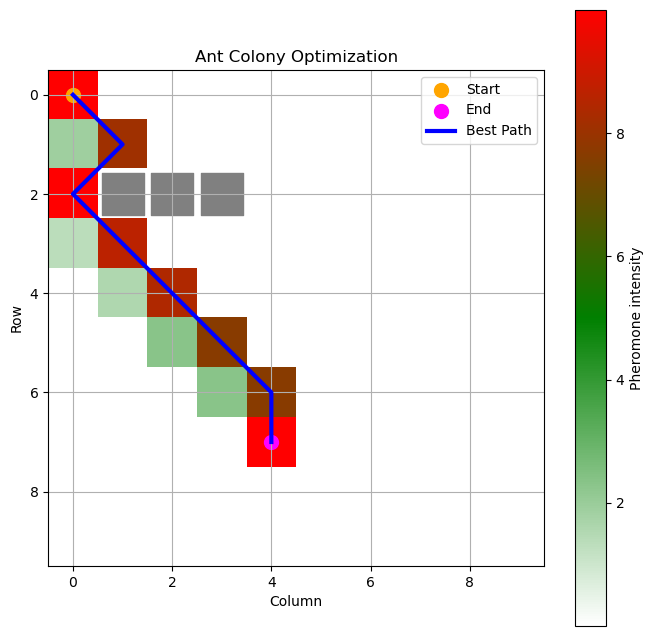

End of Ant Colony Optimization
Best path:  [(0, 0), (1, 1), (0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (4, 7)]
Start of Ant Colony Optimization - Second Study Case


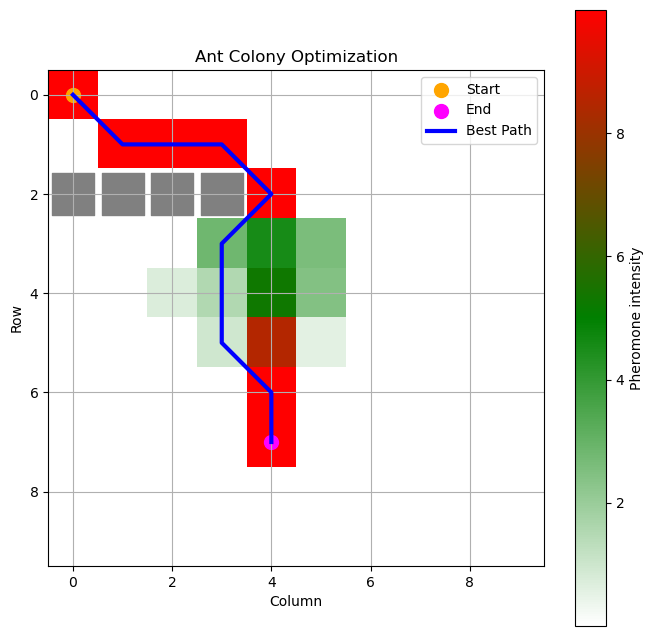

End of Ant Colony Optimization
Best path:  [(0, 0), (1, 1), (2, 1), (3, 1), (4, 2), (3, 3), (3, 4), (3, 5), (4, 6), (4, 7)]

  GRID SEARCH (81 combinaciones)
  [20/81] mejor hasta ahora: longitud=8
  [40/81] mejor hasta ahora: longitud=8
  [60/81] mejor hasta ahora: longitud=8
  [80/81] mejor hasta ahora: longitud=8
  [81/81] mejor hasta ahora: longitud=8
Mejores hiperparámetros (Grid Search): {'num_ants': 5, 'evaporation_rate': 0.05, 'alpha': 0.1, 'beta': 5}
Longitud del mejor camino: 8


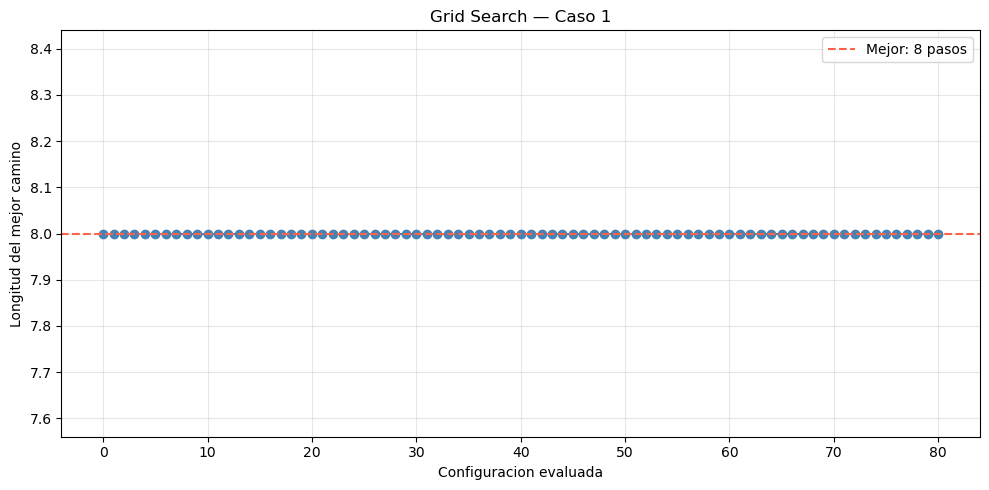

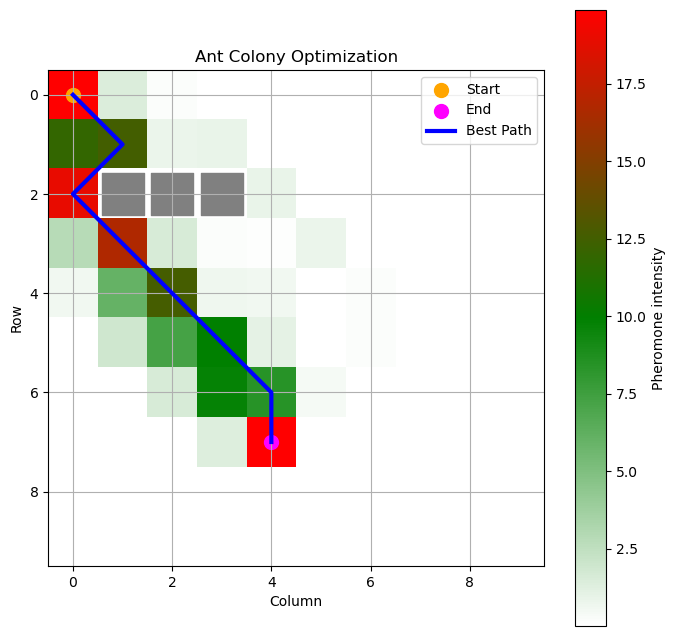


  RANDOM SEARCH (20 configuraciones aleatorias)
  Trial  1: longitud=10 | ants=8, ev=0.09, a=1.72, b=14.9
  Trial  2: longitud=10 | ants=25, ev=0.30, a=1.01, b=14.2
  Trial  3: longitud=10 | ants=29, ev=0.15, a=1.86, b=14.9
  Trial  4: longitud=10 | ants=19, ev=0.27, a=0.10, b=11.7
  Trial  5: longitud=10 | ants=28, ev=0.20, a=1.64, b=6.1
  Trial  6: longitud=10 | ants=24, ev=0.07, a=1.58, b=12.5
  Trial  7: longitud=10 | ants=8, ev=0.28, a=0.22, b=14.7
  Trial  8: longitud=10 | ants=13, ev=0.24, a=1.42, b=15.0
  Trial  9: longitud=10 | ants=8, ev=0.25, a=0.70, b=12.0
  Trial 10: longitud=10 | ants=25, ev=0.22, a=1.00, b=11.8
  Trial 11: longitud=10 | ants=11, ev=0.17, a=0.39, b=5.3
  Trial 12: longitud=10 | ants=8, ev=0.12, a=1.55, b=10.7
  Trial 13: longitud=10 | ants=18, ev=0.24, a=1.24, b=5.8
  Trial 14: longitud=10 | ants=6, ev=0.25, a=0.87, b=5.4
  Trial 15: longitud=10 | ants=22, ev=0.29, a=0.24, b=5.3
  Trial 16: longitud=10 | ants=9, ev=0.14, a=1.54, b=13.5
  Trial 17: longit

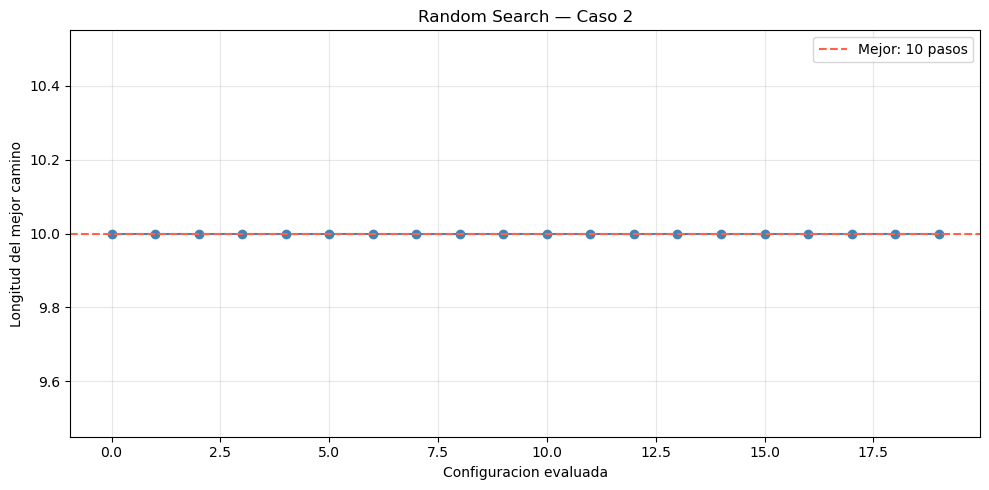

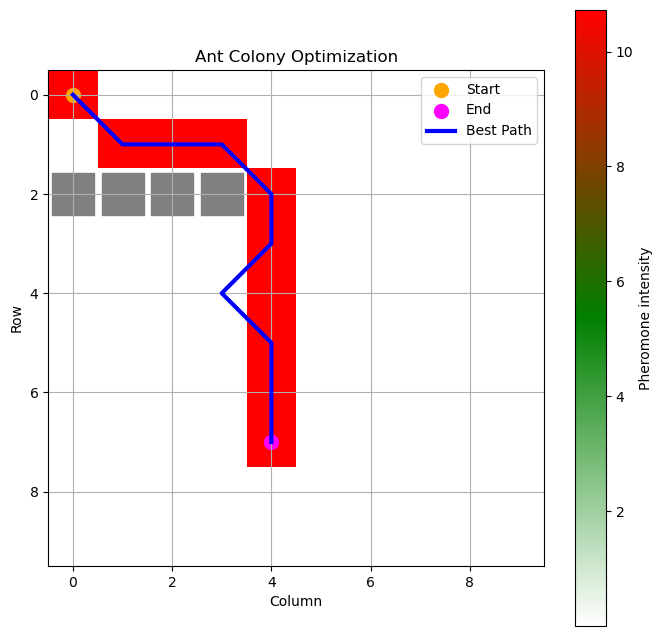

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

class AntColonyOptimization:
    def __init__(self, start, end, obstacles, grid_size=(10, 10), num_ants=10, evaporation_rate=0.1, alpha=0.1, beta=15):
        self.start = start
        self.end = end
        self.obstacles = obstacles
        self.grid_size = grid_size
        self.num_ants = num_ants
        self.evaporation_rate = evaporation_rate
        self.alpha = alpha
        self.beta = beta
        self.pheromones = np.ones(grid_size)
        self.best_path = None

    def _get_neighbors(self, position):
        pos_x, pos_y = position
        neighbors = []
        for i in range(-1, 2):
            for j in range(-1, 2):
                new_x, new_y = pos_x + i, pos_y + j
                if (0 <= new_x < self.grid_size[0] and 0 <= new_y < self.grid_size[1] and
                        (new_x, new_y) != position and (new_x, new_y) not in self.obstacles):
                    neighbors.append((new_x, new_y))
        return neighbors

    def _select_next_position(self, position, visited):
        neighbors = self._get_neighbors(position)
        probabilities = []
        total = 0
        for neighbor in neighbors:
            if neighbor not in visited:
                pheromone = self.pheromones[neighbor[1], neighbor[0]]
                heuristic = 1 / (np.linalg.norm(np.array(neighbor) - np.array(self.end)) + 0.1)
                probabilities.append((neighbor, pheromone ** self.alpha * heuristic ** self.beta))
                total += pheromone ** self.alpha * heuristic ** self.beta
        if not probabilities:
            return None
        probabilities = [(pos, prob / total) for pos, prob in probabilities]
        selected = np.random.choice(len(probabilities), p=[prob for pos, prob in probabilities])
        return probabilities[selected][0]

    def _evaporate_pheromones(self):
        self.pheromones *= (1 - self.evaporation_rate)

    def _deposit_pheromones(self, path):
        for position in path:
            self.pheromones[position[1], position[0]] += 1

    def find_best_path(self, num_iterations):
        for _ in range(num_iterations):
            all_paths = []
            for _ in range(self.num_ants):
                current_position = self.start
                path = [current_position]
                while current_position != self.end:
                    next_position = self._select_next_position(current_position, path)
                    if next_position is None:
                        break
                    path.append(next_position)
                    current_position = next_position
                all_paths.append(path)

            # Escoger el mejor camino por su tamaño?
            # --------------------------
            #all_paths.sort(key=lambda x: len(x))
            #best_path = all_paths[0]

            # ✅ CORRECCIÓN DEL BUG:
            # Filtrar SOLO los caminos que llegaron al destino.
            # Sin este filtro, se podria premiar una ruta incompleta
            # (pero corta) sobre una ruta completa mas larga, lo que
            # lleva a depositar feromonas en un camino equivocado.
            valid_paths = [p for p in all_paths if p[-1] == self.end]
 
            # Si ninguna hormiga llego al destino en esta iteracion,
            # solo evaporar sin depositar feromonas.
            if not valid_paths:
                self._evaporate_pheromones()
                continue
 
            # Seleccionar el mas corto entre los caminos validos
            valid_paths.sort(key=lambda x: len(x))
            best_path = valid_paths[0]

            self._evaporate_pheromones()
            self._deposit_pheromones(best_path)

            if self.best_path is None or len(best_path) < len(self.best_path):
                self.best_path = best_path
            # --------------------------

    def plot(self):
        cmap = LinearSegmentedColormap.from_list('pheromone', ['white', 'green', 'red'])
        plt.figure(figsize=(8, 8))
        plt.imshow(self.pheromones, cmap=cmap, vmin=np.min(self.pheromones), vmax=np.max(self.pheromones))
        plt.colorbar(label='Pheromone intensity')
        plt.scatter(self.start[0], self.start[1], color='orange', label='Start', s=100)
        plt.scatter(self.end[0], self.end[1], color='magenta', label='End', s=100)
        for obstacle in self.obstacles:
            plt.scatter(obstacle[0], obstacle[1], color='gray', s=900, marker='s')
        if self.best_path:
            path_x, path_y = zip(*self.best_path)
            plt.plot(path_x, path_y, color='blue', label='Best Path', linewidth=3)
        plt.xlabel('Column')
        plt.ylabel('Row')
        plt.title('Ant Colony Optimization')
        plt.legend()
        plt.grid(True)
        plt.show()

import random
from itertools import product
import matplotlib.pyplot as plt

class ACOOptimizer:
    def __init__(self, start, end, obstacles, grid_size=(10, 10)):
        self.start = start
        self.end = end
        self.obstacles = obstacles
        self.grid_size = grid_size

    def _evaluate(self, params, num_iterations=50):
        """
        Ejecuta el ACO con una configuracion dada y retorna la longitud
        del mejor camino encontrado. Si no llega al destino, retorna inf.
        """
        aco = AntColonyOptimization(
            start=self.start,
            end=self.end,
            obstacles=self.obstacles,
            grid_size=self.grid_size,
            num_ants=params['num_ants'],
            evaporation_rate=params['evaporation_rate'],
            alpha=params['alpha'],
            beta=params['beta'],
        )
        aco.find_best_path(num_iterations)

        # ✅ Validar que el camino sea completo (llegue al destino)
        if aco.best_path and aco.best_path[-1] == self.end:
            return len(aco.best_path)
        return float('inf')
    
    # ---------------------------------------------------------
    # RANDOM SEARCH
    # ---------------------------------------------------------
    def random_search(self, num_trials=20, num_iterations=50):
        """
        Muestrea num_trials configuraciones aleatorias dentro de rangos
        continuos y retorna la mejor encontrada.
 
        Ventaja sobre Grid Search: explora valores intermedios del espacio
        continuo, especialmente util cuando hay muchos hiperparametros
        o rangos amplios [Bergstra & Bengio, 2012].
        """
        results     = []
        best_config = None
        best_length = float('inf')
 
        print(f"\n{'='*55}")
        print(f"  RANDOM SEARCH ({num_trials} configuraciones aleatorias)")
        print(f"{'='*55}")
 
        for i in range(num_trials):
            params = {
                'num_ants'         : random.randint(5, 30),
                'evaporation_rate' : random.uniform(0.05, 0.3),
                'alpha'            : random.uniform(0.1, 2.0),
                'beta'             : random.uniform(5.0, 20.0),
            }
 
            length = self._evaluate(params, num_iterations)
            results.append((params, length))
 
            if length < best_length:
                best_length = length
                best_config = params
 
            status = f"longitud={length}" if length < float('inf') else "no llego"
            print(f"  Trial {i+1:2d}: {status} | "
                  f"ants={params['num_ants']}, "
                  f"ev={params['evaporation_rate']:.2f}, "
                  f"a={params['alpha']:.2f}, b={params['beta']:.1f}")
 
        return best_config, best_length, results
 
    # ------------------------------------------------------------------
    # GRID SEARCH
    # ------------------------------------------------------------------
    def grid_search(self, num_iterations=50):
        """
        Evalua todas las combinaciones posibles de la grilla de
        hiperparametros. Garantiza encontrar la mejor configuracion
        dentro del espacio discreto definido.
 
        Adecuado cuando el espacio de busqueda es pequeno y discreto,
        como en este laberinto de 10x10.
        """
        param_grid = {
            'num_ants'         : [5, 10, 20],
            'evaporation_rate' : [0.05, 0.1, 0.2],
            'alpha'            : [0.1, 0.5, 1.0],
            'beta'             : [5, 10, 15],
        }
 
        keys         = list(param_grid.keys())
        combinations = list(product(*param_grid.values()))
        total        = len(combinations)
 
        results     = []
        best_config = None
        best_length = float('inf')
 
        print(f"\n{'='*55}")
        print(f"  GRID SEARCH ({total} combinaciones)")
        print(f"{'='*55}")
 
        for i, combo in enumerate(combinations):
            params = dict(zip(keys, combo))
            length = self._evaluate(params, num_iterations)
            results.append((params, length))
 
            if length < best_length:
                best_length = length
                best_config = params
 
            # Mostrar progreso cada 20 combinaciones
            if (i + 1) % 20 == 0 or (i + 1) == total:
                status = f"mejor hasta ahora: longitud={best_length}"
                print(f"  [{i+1:2d}/{total}] {status}")
 
        return best_config, best_length, results
 
    # ------------------------------------------------------------------
    # PLOT RESULTS
    # ------------------------------------------------------------------
    def plot_results(self, results, title='Optimizacion ACO'):
        """
        Grafica la longitud del camino para cada configuracion evaluada.
        Los puntos en inf se omiten (configuraciones que no llegaron).
        """
        lengths = [r[1] for r in results]
        valid   = [(i, l) for i, l in enumerate(lengths) if l < float('inf')]
 
        if not valid:
            print("Ninguna configuracion encontro el camino al destino.")
            return
 
        x_vals, y_vals = zip(*valid)
 
        plt.figure(figsize=(10, 5))
        plt.plot(x_vals, y_vals, marker='o', color='steelblue', linewidth=1.5)
        plt.axhline(min(y_vals), color='tomato', linestyle='--',
                    label=f'Mejor: {min(y_vals)} pasos')
        plt.title(title)
        plt.xlabel('Configuracion evaluada')
        plt.ylabel('Longitud del mejor camino')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()



def study_case_1():
    print("Start of Ant Colony Optimization - First Study Case")
    start = (0, 0)
    end = (4, 7)
    obstacles = [(1, 2), (2, 2), (3, 2)]
    aco = AntColonyOptimization(start, end, obstacles)
    aco.find_best_path(100)
    aco.plot()
    print("End of Ant Colony Optimization")
    print("Best path: ", aco.best_path)

def study_case_2():
    print("Start of Ant Colony Optimization - Second Study Case")
    start = (0, 0)
    end = (4, 7)
    obstacles = [(0, 2), (1, 2), (2, 2), (3, 2)]
    aco = AntColonyOptimization(start, end, obstacles)
    aco.find_best_path(100)
    aco.plot()
    print("End of Ant Colony Optimization")
    print("Best path: ", aco.best_path)

def optimize_case_1_grid():
    optimizer = ACOOptimizer(
        start=(0, 0),
        end=(4, 7),
        obstacles=[(1, 2), (2, 2), (3, 2)]
    )

    best_config, best_length, results = optimizer.grid_search()

    print("Mejores hiperparámetros (Grid Search):", best_config)
    print("Longitud del mejor camino:", best_length)

    optimizer.plot_results(results, title='Grid Search — Caso 1')


# Correr ACO final con la mejor configuracion
    aco = AntColonyOptimization(
        start=(0, 0), end=(4, 7),
        obstacles=[(1, 2), (2, 2), (3, 2)],
        num_ants=best_config['num_ants'],
        evaporation_rate=best_config['evaporation_rate'],
        alpha=best_config['alpha'],
        beta=best_config['beta'],
    )
    aco.find_best_path(100)
    aco.plot()
    
def optimize_case_2_random():

    optimizer = ACOOptimizer(
        start=(0, 0),
        end=(4, 7),
        obstacles=[(0, 2), (1, 2), (2, 2), (3, 2)],
    )
 
    best_config, best_length, results = optimizer.random_search(
        num_trials=20, num_iterations=50
    )
 
    if best_config:
        print(f"\n  Mejores hiperparametros (Random Search):")
        for k, v in best_config.items():
            print(f"    {k:20s}: {v:.4f}" if isinstance(v, float) else
                  f"    {k:20s}: {v}")
        print(f"  Longitud del mejor camino: {best_length}")
 
        optimizer.plot_results(results, title='Random Search — Caso 2')
 
        # Correr ACO final con la mejor configuracion
        aco = AntColonyOptimization(
            start=(0, 0), end=(4, 7),
            obstacles=[(0, 2), (1, 2), (2, 2), (3, 2)],
            num_ants=best_config['num_ants'],
            evaporation_rate=best_config['evaporation_rate'],
            alpha=best_config['alpha'],
            beta=best_config['beta'],
        )
        aco.find_best_path(100)
        aco.plot()
    else:
        print("  Random Search no encontro ninguna configuracion valida.")

if __name__ == '__main__':
    study_case_1()
    study_case_2()
    optimize_case_1_grid()
    optimize_case_2_random()

## Conclusiones

### Sobre el bug corregido
El error consistía en premiar rutas incompletas con depósito de
feromonas, desviando al enjambre de la solución correcta. La corrección
filtra únicamente los caminos donde `path[-1] == end` antes de
seleccionar el mejor, y si ninguna hormiga llegó al destino en esa
iteración, solo se aplica evaporación sin reforzar ningún camino.

### Sobre los casos de estudio
El Caso 1 (barrera parcial) es resuelto fácilmente con los parámetros
por defecto. El Caso 2 (barrera completa) es donde la optimización de
hiperparámetros tiene mayor impacto: sin una buena configuración, el
ACO puede no encontrar el camino consistentemente.

### Sobre Grid Search vs Random Search
Grid Search es suficiente para este problema dado su espacio de
búsqueda pequeño (81 combinaciones). Random Search es más adecuado
para el Caso 2, donde explorar rangos continuos aumenta la probabilidad
de encontrar configuraciones válidas con menos evaluaciones
[Bergstra & Bengio, 2012].

### Sobre los parámetros más influyentes
`beta` es el parámetro más crítico: valores altos (≥ 10) permiten que
la heurística de distancia guíe eficientemente a las hormigas,
especialmente en las primeras iteraciones cuando las feromonas aún no
están consolidadas.